In [1]:
import pandas as pd
import json
from pandas import json_normalize
import os

In [2]:
with open('categorized_tasks-gpt-4o-gpt-4o-airline.json', 'r') as f:
    data = json.load(f)
df = json_normalize(
    data,
    record_path=["conversations"],
    meta=["Task id"],  # bring parent key along
)
df.head()

,intent,conversation_segment,category,reasoning,Task id
0,BOOK,User: Hi! I'm looking to book a flight from Ne...,procedural,The conversation is procedural because the use...,0
1,MODIFY,User: Hi there! I need to change my return fli...,declarative,The conversation is declarative because the us...,1
2,CANCEL,User: I must have left it somewhere else. If b...,declarative,The conversation is declarative because the us...,1
3,MODIFY,User: Hey there. I'm having some issues with m...,procedural,The conversation is procedural because the use...,2
4,MODIFY,User: Hi! I need to change my flight back from...,procedural,The conversation is procedural because the use...,3


In [9]:
df[["Task id", "intent","conversation_segment","reasoning","category"]].to_csv("csv's/categorized_tasks-gpt-4o-gpt-4o-airline.csv", index=False)


In [4]:
df[df["Task id"] == 10]

,intent,conversation_segment,category,reasoning,Task id
16,MODIFY,User: Hi! I need to make a change to my reserv...,declarative,The conversation is declarative because the us...,10
17,CANCEL,User: That's okay. Let's just cancel the entir...,declarative,The conversation is declarative because the us...,10
18,BOOK,"User: Alright, thank you. Can you now help me ...",procedural,The conversation is procedural because the use...,10


In [5]:
df_counts = df.groupby(["Task id", "category"]) \
.size()  \
.unstack(fill_value=0)  \
.reset_index()
df_counts

category,Task id,declarative,procedural
0,0,0,1
1,1,2,0
2,2,0,1
3,3,0,1
4,4,2,1
5,5,1,0
6,6,0,1
7,7,0,1
8,8,2,1
9,9,2,0


In [6]:
df_counts["sub_tasks"] = df_counts["procedural"] + df_counts["declarative"]
df_counts["procedural_ratio"] =  df_counts["procedural"] / df_counts["sub_tasks"]
df_counts["declarative_ratio"] =  df_counts["declarative"] / df_counts["sub_tasks"]
df_counts.to_csv("csv's/task_category_counts_ratio-gpt-4o-gpt-4o-airline.csv", index=False)

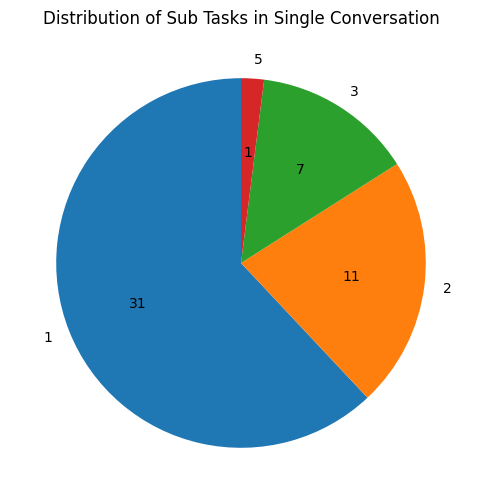

In [8]:
import matplotlib.pyplot as plt

# Count occurrences of each unique value
subtask_counts = df_counts["sub_tasks"].value_counts()

# Custom function to show counts
def absolute_value(pct, all_vals):
    total = sum(all_vals)
    count = int(round(pct * total / 100.0))
    return f"{count}"

# Create pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    subtask_counts,
    labels=subtask_counts.index,
    autopct=lambda pct: absolute_value(pct, subtask_counts),
    startangle=90
)
plt.title("Distribution of Sub Tasks in Single Conversation")
plt.show()

In [7]:
df_tasks_counts = df.groupby(["intent", "category"]) \
.size()  \
.unstack(fill_value=0)  \
.reset_index()
df_tasks_counts

category,intent,declarative,procedural
0,BOOK,1,8
1,CANCEL,15,9
2,MODIFY,23,23


In [8]:
df_tasks_counts.to_csv("csv's/task_category_counts-gpt-4o-gpt-4o-airline.csv", index=False)

In [10]:
grouped = df.groupby(["intent", "category"])
_df_tasks_counts = grouped.size().reset_index(name="count")
df_taskids = grouped["Task id"].apply(list).reset_index(name="task_ids")
df_tasks_counts_withids = _df_tasks_counts.merge(df_taskids, on=["intent", "category"], how="left")
df_tasks_counts_withids

,intent,category,count,task_ids
0,BOOK,declarative,1,[8]
1,BOOK,procedural,8,"[0, 10, 11, 21, 25, 32, 46, 46]"
2,CANCEL,declarative,15,"[1, 9, 10, 12, 18, 26, 27, 30, 31, 34, 35, 38,..."
3,CANCEL,procedural,9,"[8, 15, 25, 28, 29, 31, 33, 41, 47]"
4,MODIFY,declarative,23,"[1, 4, 4, 5, 8, 9, 10, 11, 15, 16, 19, 21, 23,..."
5,MODIFY,procedural,23,"[2, 3, 4, 6, 7, 11, 13, 14, 15, 17, 20, 22, 23..."


In [11]:
df_tasks_counts_withids.to_csv("csv's/task_category_counts_withids-gpt-4o-gpt-4o-airline.csv", index=False)

In [12]:
df_counts["procedural_flag"] = df_counts["procedural"].apply(lambda x: "yes" if x > 0 else "no")
df_counts["declarative_flag"] = df_counts["declarative"].apply(lambda x: "yes" if x > 0 else "no")
df_counts["sub_tasks"] = df_counts["procedural"] + df_counts["declarative"]

In [14]:
df_counts[df_counts["sub_tasks"] == 3]

category,Task id,declarative,procedural,sub_tasks,procedural_ratio,declarative_ratio,procedural_flag,declarative_flag
4,4,2,1,3,0.333333,0.666667,yes,yes
8,8,2,1,3,0.333333,0.666667,yes,yes
10,10,2,1,3,0.333333,0.666667,yes,yes
11,11,1,2,3,0.666667,0.333333,yes,yes
15,15,1,2,3,0.666667,0.333333,yes,yes
33,33,0,3,3,1.000000,0.000000,yes,no
46,46,1,2,3,0.666667,0.333333,yes,yes


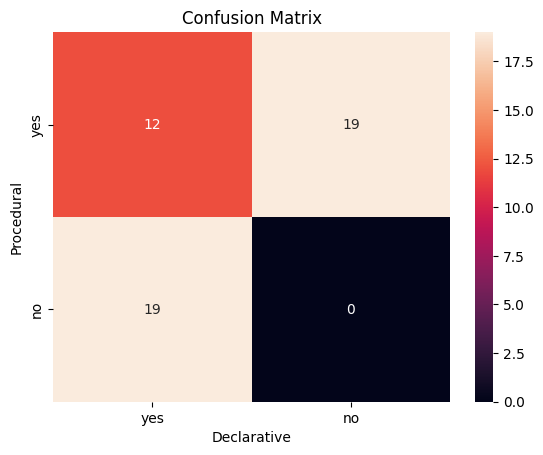

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(df_counts['procedural_flag'], df_counts['declarative_flag'], labels=['yes', 'no'])

# Plot confusion matrix
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['yes', 'no'], yticklabels=['yes', 'no'])
plt.xlabel('Declarative')
plt.ylabel('Procedural')
plt.title('Confusion Matrix')
plt.show()